<a href="https://colab.research.google.com/github/Abraham353/Laboratorio_08-MD/blob/develop/Laboratoio_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LABORATORIO 09: ÁRBOLES DE DECISIÓN. BOSQUES ALEATORIOS

### INTEGRANTES
- AQUINO REYES BENJY ALVARO
- HUAMAN QUISPE ABRAHAM SEBASTIAN JONATHAN

### A.- Lea la base de datos, realice imputaciones, tratamiento de outliers, transformaciones de datos y desbalance de clases en caso sea necesario. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos.

In [2]:
# Importar librerías necesarias
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargar el dataset de cáncer de mama
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# Verificar valores nulos
print("Valores nulos por columna:")
print(X.isnull().sum())

# Verificar balance de clases
print("\nDistribución de clases:")
print(y.value_counts())

# Dividir los datos en entrenamiento (75%) y prueba (25%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Estandarizar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nForma de los conjuntos de datos:")
print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Valores nulos por columna:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

Distribución de clases:
target
1    357
0    212
Name: count, dtype: int64

Forma de los 

### B.- Genere el modelo de árbol de decisión para clasificación y la profundidad adecuada para este. Además, calcule las métricas de clasificación e interprete sus resultados más importantes.

=== Métricas del Árbol de Decisión ===
Exactitud (Accuracy): 0.9371
F1-Score: 0.9503

Reporte de Clasificación:
              precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        53
      benign       0.95      0.96      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143


Matriz de Confusión:
[[48  5]
 [ 4 86]]


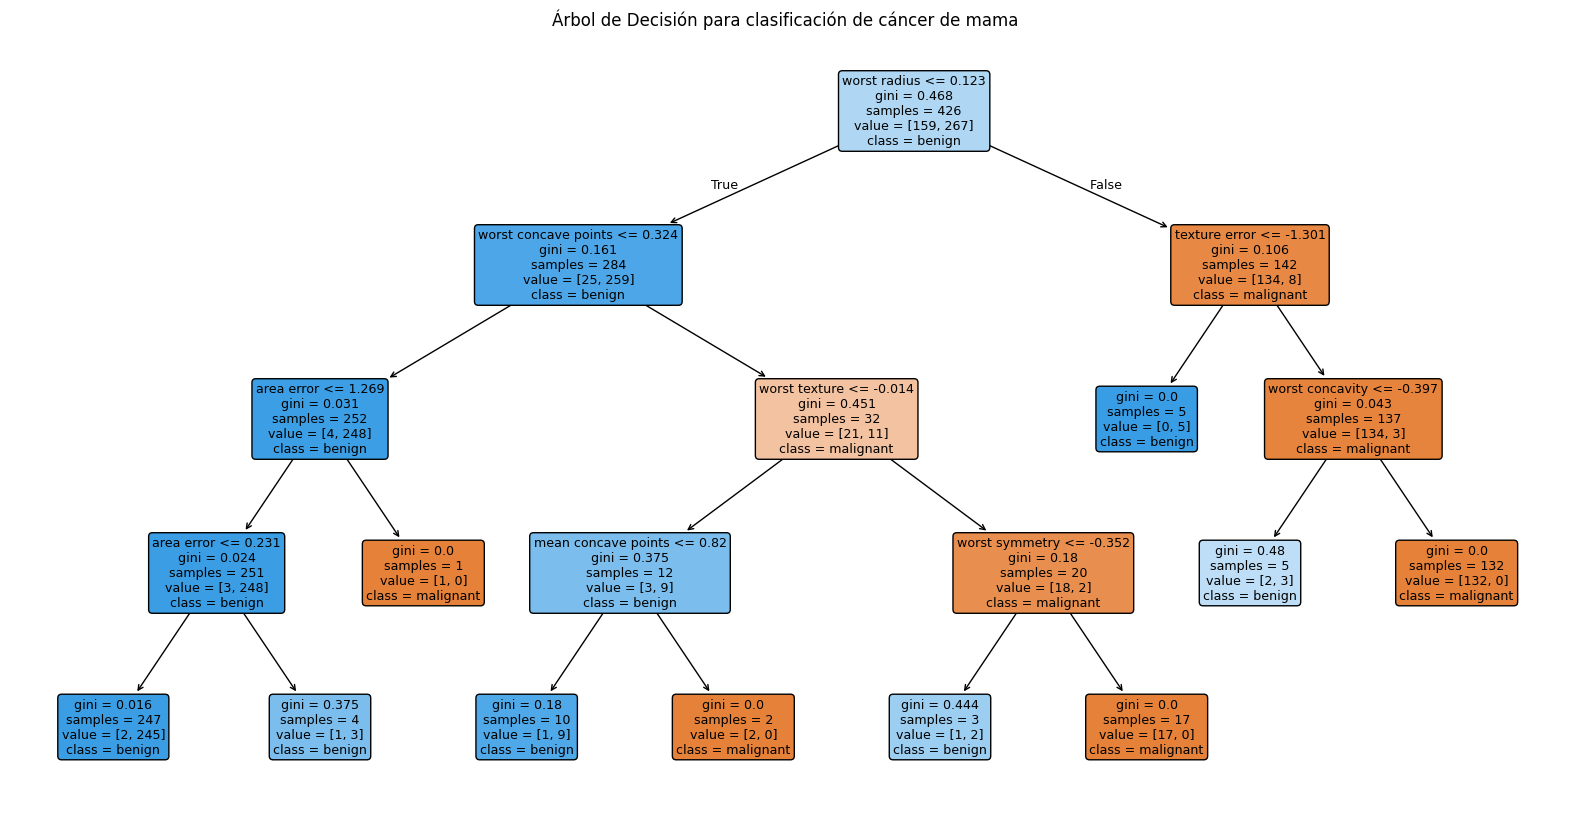


Top 10 características más importantes:
                 Feature  Importance
20          worst radius    0.736092
27  worst concave points    0.123670
11         texture error    0.049015
21         worst texture    0.033655
26       worst concavity    0.018420
7    mean concave points    0.014338
13            area error    0.012774
28        worst symmetry    0.012037
3              mean area    0.000000
4        mean smoothness    0.000000


In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                            classification_report, f1_score)
import matplotlib.pyplot as plt

# Crear y entrenar el modelo de árbol de decisión
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,  # Limitamos la profundidad para evitar overfitting
    min_samples_split=10,
    random_state=42
)
dt_model.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred_dt = dt_model.predict(X_test)

# Métricas de evaluación
print("=== Métricas del Árbol de Decisión ===")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_dt, target_names=data.target_names))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_dt))

# Visualizar el árbol
plt.figure(figsize=(20,10))
plot_tree(dt_model,
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True, rounded=True)
plt.title("Árbol de Decisión para clasificación de cáncer de mama")
plt.show()

# Importancia de características
importances = dt_model.feature_importances_
features = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 10 características más importantes:")
print(features.head(10))

### C.- Genere el modelo de bosques aleatorios para clasificación. Además, calcule las métricas de clasificación y compárelas con las del árbol de clasificación. ¿Hubo mejoras o no?


=== Métricas de Bosques Aleatorios ===
Exactitud (Accuracy): 0.9580
F1-Score: 0.9670

Reporte de Clasificación:
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143


Matriz de Confusión:
[[49  4]
 [ 2 88]]

=== Comparación de Modelos ===
Exactitud Árbol de Decisión: 0.9371
Exactitud Bosques Aleatorios: 0.9580
Mejora: 0.0210

Top 10 características más importantes en Bosques Aleatorios:
                 Feature  Importance
23            worst area    0.155311
27  worst concave points    0.130525
7    mean concave points    0.113860
20          worst radius    0.091440
22       worst perimeter    0.089171
2         mean perimeter    0.082690
0            mean radius    0.054372
6         mean concavity    0.053995
3  

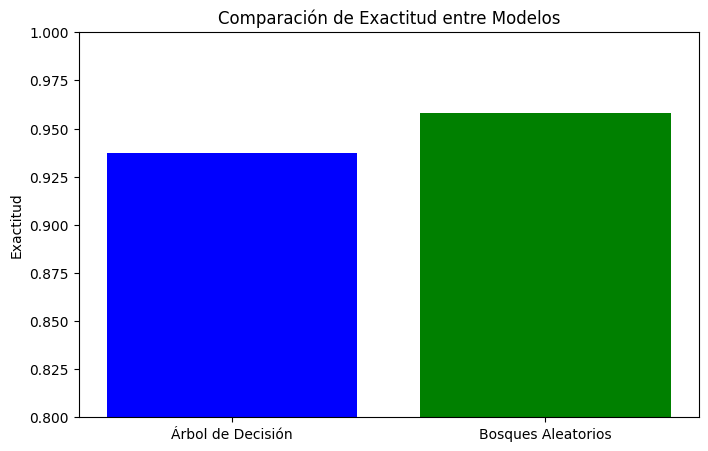

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Crear y entrenar el modelo de bosques aleatorios
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Métricas de evaluación
print("\n=== Métricas de Bosques Aleatorios ===")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=data.target_names))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))

# Comparación de modelos
print("\n=== Comparación de Modelos ===")
print(f"Exactitud Árbol de Decisión: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Exactitud Bosques Aleatorios: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Mejora: {accuracy_score(y_test, y_pred_rf) - accuracy_score(y_test, y_pred_dt):.4f}")

# Importancia de características en el bosque
rf_importances = rf_model.feature_importances_
rf_features = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False)

print("\nTop 10 características más importantes en Bosques Aleatorios:")
print(rf_features.head(10))

# Gráfico comparativo de precisión
plt.figure(figsize=(8,5))
plt.bar(['Árbol de Decisión', 'Bosques Aleatorios'],
        [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
        color=['blue', 'green'])
plt.title('Comparación de Exactitud entre Modelos')
plt.ylabel('Exactitud')
plt.ylim(0.8, 1.0)
plt.show()